In [1]:
# libraries and settings

import os
import json
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

# reproducibility
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

    TORCH_AVAILABLE = True

except ImportError:
    TORCH_AVAILABLE = False

print("Torch available:", TORCH_AVAILABLE)

if not TORCH_AVAILABLE:
    raise ImportError("PyTorch is not installed. Please install it with: pip install torch")

RANDOM_STATE

Torch available: True


42

In [2]:
# device selection

# CPU is used for better reproducibility across different machines.
# GPU/MPS can be faster, but may introduce small numerical differences.

DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: cpu


In [3]:
# load model data and fixed splits

MODEL_DATA_FILE = "model_df.pkl"
FEATURE_LIST_FILE = "model_feature_cols.txt"
SPLIT_DIR = Path("splits")

model_df = pd.read_pickle(MODEL_DATA_FILE)

with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as f:
    model_feature_cols = [line.strip() for line in f.readlines()]

train_indices = pd.read_csv(SPLIT_DIR / "train_indices.csv")["index"].to_numpy()
validation_indices = pd.read_csv(SPLIT_DIR / "validation_indices.csv")["index"].to_numpy()
test_indices = pd.read_csv(SPLIT_DIR / "test_indices.csv")["index"].to_numpy()

print("model_df shape:", model_df.shape)
print("Total feature count:", len(model_feature_cols))

print("\nSplit sizes:")
print("Train      :", len(train_indices))
print("Validation :", len(validation_indices))
print("Test       :", len(test_indices))

display(model_df.head())

model_df shape: (359, 793)
Total feature count: 784

Split sizes:
Train      : 251
Validation : 54
Test       : 54


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10,future_mid_close,future_mid_return,target,target_label,mid_open_lag_1,mid_open_lag_2,mid_open_lag_3,mid_open_lag_5,mid_open_lag_10,mid_open_lag_15,mid_open_lag_30,mid_open_roll_mean_3,mid_open_roll_std_3,mid_open_roll_min_3,mid_open_roll_max_3,mid_open_roll_mean_5,mid_open_roll_std_5,...,mid_return_1m_lag_10,mid_return_1m_lag_15,mid_return_1m_lag_30,mid_return_1m_roll_mean_3,mid_return_1m_roll_std_3,mid_return_1m_roll_min_3,mid_return_1m_roll_max_3,mid_return_1m_roll_mean_5,mid_return_1m_roll_std_5,mid_return_1m_roll_min_5,mid_return_1m_roll_max_5,mid_return_1m_roll_mean_10,mid_return_1m_roll_std_10,mid_return_1m_roll_min_10,mid_return_1m_roll_max_10,mid_return_1m_roll_mean_15,mid_return_1m_roll_std_15,mid_return_1m_roll_min_15,mid_return_1m_roll_max_15,mid_return_1m_roll_mean_30,mid_return_1m_roll_std_30,mid_return_1m_roll_min_30,mid_return_1m_roll_max_30,mid_log_return_1m_lag_1,mid_log_return_1m_lag_2,mid_log_return_1m_lag_3,mid_log_return_1m_lag_5,mid_log_return_1m_lag_10,mid_log_return_1m_lag_15,mid_log_return_1m_lag_30,mid_log_return_1m_roll_mean_3,mid_log_return_1m_roll_std_3,mid_log_return_1m_roll_min_3,mid_log_return_1m_roll_max_3,mid_log_return_1m_roll_mean_5,mid_log_return_1m_roll_std_5,mid_log_return_1m_roll_min_5,mid_log_return_1m_roll_max_5,mid_log_return_1m_roll_mean_10,mid_log_return_1m_roll_std_10,mid_log_return_1m_roll_min_10,mid_log_return_1m_roll_max_10,mid_log_return_1m_roll_mean_15,mid_log_return_1m_roll_std_15,mid_log_return_1m_roll_min_15,mid_log_return_1m_roll_max_15,mid_log_return_1m_roll_mean_30,mid_log_return_1m_roll_std_30,mid_log_return_1m_roll_min_30,mid_log_return_1m_roll_max_30
0,600,30.885,30.815,30.835212,0.014353,0.005530,0.03,0.000465,32824.956917,23607.855755,-0.160153,-0.205123,-0.176975,-0.154065,-121900.0,-25.744456,492.695370,4735,2034700,82237,2342,19,2045,329,-0.07,-0.163329,0.069483,-0.07,-0.002269,10,0,10:00,30.893,30.785,-0.03,0,down,30.905,30.895,30.895,30.925,30.925,30.995,30.970,30.898333,0.005774,30.895,30.905,30.907,0.013038,...,-0.02,-0.04,0.000,-0.003333,0.015275,-0.02,0.01,-0.008,0.013038,-0.02,0.01,-0.004,0.016465,-0.02,0.02,-0.007333,0.017099,-0.04,0.02,-0.004833,0.025444,-0.06,0.05,-0.000647,0.000324,0.000000,-0.000323,-0.000647,-0.001291,0.000000,-0.000108,0.000494,-0.000647,0.000324,-0.000259,0.000422,-0.000647,0.000324,-0.000129,0.000533,-0.000647,0.000647,-0.000237,0.000553,-0.001291,0.000647,-0.000156,0.000821,-0.001938,0.001611
1,601,30.815,30.785,30.802364,0.013313,0.004708,0.02,0.000432,32973.961183,38181.424677,0.229252,0.193269,0.073428,-0.117912,-47503.0,-21.951479,418.168737,2164,865804,38198,1090,10,922,142,-0.03,0.073184,0.065619,-0.03,-0.000974,10,1,10:01,30.883,30.765,-0.02,0,down,30.885,30.905,30.895,30.915,30.905,30.955,31.030,30.895000,0.010000,30.885,30.905,30.899,0.011402,...,-0.02,-0.01,0.045,-0.026667,0.040415,-0.07,0.01,-0.020,0.030822,-0.07,0.01,-0.009,0.026437,-0.07,0.02,-0.009333,0.022190,-0.07,0.02,-0.007167,0.028060,-0.07,0.05,-0.002269,-0.000647,0.000324,-0.000647,-0.000647,-0.000323,0.001449,-0.000864,0.001310,-0.002269,0.000324,-0.000648,0.000999,-0.002269,0.000324,-0.000292,0.000856,-0.002269,0.000647,-0.000302,0.000719,-0.002269,0.000647,-0.000232,0.000906,-0.002269,0.001611
2,602,30.785,30.765,30.783377,0.011774,0.003821,0.02,0.000382,51552.850716,54422.674847,0.044643,0.060605,0.038961,-0.085354,-84651.0,-43.277607,580.001979,1956,992787,29994,1003,12,837,104,-0.02,0.027080,0.053170,-0.02,-0.000650,10,2,10:02,30.869,30.745,-0.02,0,down,30.815,30.885,30.905,30.895,30.885,30.945,31.075,30.868333,0.047258,30.815,30.905,3

In [4]:
# create train / validation / test dataframes

train_df = model_df.iloc[train_indices].copy()
validation_df = model_df.iloc[validation_indices].copy()
test_df = model_df.iloc[test_indices].copy()

print("Train shape      :", train_df.shape)
print("Validation shape :", validation_df.shape)
print("Test shape       :", test_df.shape)

print("\nTrain minute range:")
print(train_df["minute"].min(), "→", train_df["minute"].max())

print("\nValidation minute range:")
print(validation_df["minute"].min(), "→", validation_df["minute"].max())

print("\nTest minute range:")
print(test_df["minute"].min(), "→", test_df["minute"].max())

print("\nTrain target distribution:")
display(train_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nValidation target distribution:")
display(validation_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nTest target distribution:")
display(test_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

Train shape      : (251, 793)
Validation shape : (54, 793)
Test shape       : (54, 793)

Train minute range:
600 → 850

Validation minute range:
851 → 904

Test minute range:
905 → 958

Train target distribution:


target_label
down    0.299
flat    0.466
up      0.235
Name: proportion, dtype: float64


Validation target distribution:


target_label
down    0.259
flat    0.630
up      0.111
Name: proportion, dtype: float64


Test target distribution:


target_label
down    0.370
flat    0.352
up      0.278
Name: proportion, dtype: float64

In [5]:
# time order and split boundary check

time_split_check = {
    "model_df_time_ordered": model_df["minute"].is_monotonic_increasing,
    "train_time_ordered": train_df["minute"].is_monotonic_increasing,
    "validation_time_ordered": validation_df["minute"].is_monotonic_increasing,
    "test_time_ordered": test_df["minute"].is_monotonic_increasing,
    "train_before_validation": train_df["minute"].max() < validation_df["minute"].min(),
    "validation_before_test": validation_df["minute"].max() < test_df["minute"].min(),
}

display(pd.DataFrame([time_split_check]))

assert time_split_check["model_df_time_ordered"], "model_df zaman sıralı değil."
assert time_split_check["train_time_ordered"], "Train set zaman sıralı değil."
assert time_split_check["validation_time_ordered"], "Validation set zaman sıralı değil."
assert time_split_check["test_time_ordered"], "Test set zaman sıralı değil."
assert time_split_check["train_before_validation"], "Train ve validation zaman sınırı hatalı."
assert time_split_check["validation_before_test"], "Validation ve test zaman sınırı hatalı."

print("Time order and split boundary checks passed.")

,model_df_time_ordered,train_time_ordered,validation_time_ordered,test_time_ordered,train_before_validation,validation_before_test
0,True,True,True,True,True,True


Time order and split boundary checks passed.


In [6]:
# load CNN feature set

# The 1D-CNN uses the same selected feature set as Logistic Regression.
# This follows the deep learning setup in the reference notebook, where
# the LSTM model used the Logistic-selected feature set.

SELECTED_FEATURE_DIR = Path("selected_features")

with open(SELECTED_FEATURE_DIR / "logistic_selected_feature_cols.txt", "r", encoding="utf-8") as f:
    cnn_feature_cols = [line.strip() for line in f.readlines()]

missing_cnn_features = [
    col for col in cnn_feature_cols
    if col not in model_df.columns
]

if len(missing_cnn_features) > 0:
    raise KeyError(f"Missing CNN features: {missing_cnn_features}")

print("CNN feature set source: Logistic Regression selected features")
print("CNN feature count:", len(cnn_feature_cols))

print("\nFirst 30 CNN features:")
for col in cnn_feature_cols[:30]:
    print("-", col)

CNN feature set source: Logistic Regression selected features
CNN feature count: 50

First 30 CNN features:
- mid_close_roll_std_3
- price_change_lag_5
- price_change_roll_min_10
- spread_mean_roll_std_3
- spread_mean_roll_max_5
- spread_mean_roll_std_10
- spread_mean_roll_min_10
- spread_std_lag_30
- spread_std_roll_std_10
- spread_std_roll_min_30
- spread_max_lag_2
- spread_max_lag_30
- spread_max_roll_min_5
- spread_max_roll_max_15
- ask_depth_mean_lag_2
- ask_depth_mean_lag_5
- ask_depth_mean_roll_min_5
- ask_depth_mean_roll_max_10
- depth_imbalance_roll_max_30
- imbalance_1_mean_roll_min_10
- imbalance_1_mean_roll_min_30
- imbalance_3_mean_lag_10
- imbalance_3_mean_roll_std_10
- imbalance_3_mean_roll_std_15
- imbalance_3_mean_roll_min_15
- imbalance_3_mean_roll_max_30
- imbalance_10_mean_lag_10
- imbalance_10_mean_roll_std_15
- ofi_mean_lag_5
- ofi_mean_roll_std_3


In [7]:
# prepare CNN feature matrices

X_train_cnn_raw = train_df[cnn_feature_cols].copy()
X_val_cnn_raw = validation_df[cnn_feature_cols].copy()
X_test_cnn_raw = test_df[cnn_feature_cols].copy()

y_train_cnn = train_df["target"].to_numpy()
y_val_cnn = validation_df["target"].to_numpy()
y_test_cnn = test_df["target"].to_numpy()

print("X_train_cnn_raw shape:", X_train_cnn_raw.shape)
print("X_val_cnn_raw shape  :", X_val_cnn_raw.shape)
print("X_test_cnn_raw shape :", X_test_cnn_raw.shape)

print("\ny_train shape:", y_train_cnn.shape)
print("y_val shape  :", y_val_cnn.shape)
print("y_test shape :", y_test_cnn.shape)

X_train_cnn_raw shape: (251, 50)
X_val_cnn_raw shape  : (54, 50)
X_test_cnn_raw shape : (54, 50)

y_train shape: (251,)
y_val shape  : (54,)
y_test shape : (54,)


In [8]:
# scale CNN features

scaler_cnn = StandardScaler()

X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_raw)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_raw)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_raw)

print("Scaled CNN feature matrices:")
print("Train      :", X_train_cnn_scaled.shape)
print("Validation :", X_val_cnn_scaled.shape)
print("Test       :", X_test_cnn_scaled.shape)

print("\nScaler was fitted only on the train set.")

Scaled CNN feature matrices:
Train      : (251, 50)
Validation : (54, 50)
Test       : (54, 50)

Scaler was fitted only on the train set.


In [9]:
# sequence dataset function

def create_sequences(X, y, window_size):
    X_sequences = []
    y_sequences = []

    for i in range(len(X) - window_size + 1):
        X_sequences.append(X[i:i + window_size])
        y_sequences.append(y[i + window_size - 1])

    X_sequences = np.array(X_sequences, dtype=np.float32)
    y_sequences = np.array(y_sequences, dtype=np.int64)

    return X_sequences, y_sequences

In [10]:
# PyTorch Dataset class

class CNNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
# test sequence creation with default window size

DEFAULT_WINDOW_SIZE = 10

X_train_seq, y_train_seq = create_sequences(
    X_train_cnn_scaled,
    y_train_cnn,
    DEFAULT_WINDOW_SIZE
)

X_val_seq, y_val_seq = create_sequences(
    X_val_cnn_scaled,
    y_val_cnn,
    DEFAULT_WINDOW_SIZE
)

X_test_seq, y_test_seq = create_sequences(
    X_test_cnn_scaled,
    y_test_cnn,
    DEFAULT_WINDOW_SIZE
)

print("Default window size:", DEFAULT_WINDOW_SIZE)

print("\nTrain sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

print("\nTrain target shape:", y_train_seq.shape)
print("Validation target shape:", y_val_seq.shape)
print("Test target shape:", y_test_seq.shape)

Default window size: 10

Train sequence shape: (242, 10, 50)
Validation sequence shape: (45, 10, 50)
Test sequence shape: (45, 10, 50)

Train target shape: (242,)
Validation target shape: (45,)
Test target shape: (45,)


In [12]:
class SimpleCNN1DClassifier(nn.Module):
    def __init__(
        self,
        n_features,
        n_classes,
        filters,
        kernel_size,
        dropout,
        dense_units,
        pooling_type
    ):
        super().__init__()

        padding = kernel_size // 2

        self.conv_block = nn.Sequential(
            nn.Conv1d(
                in_channels=n_features,
                out_channels=filters,
                kernel_size=kernel_size,
                padding=padding
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        if pooling_type == "max":
            self.pooling = nn.AdaptiveMaxPool1d(1)
        elif pooling_type == "avg":
            self.pooling = nn.AdaptiveAvgPool1d(1)
        else:
            raise ValueError("pooling_type must be 'max' or 'avg'.")

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(filters, dense_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_units, n_classes)
        )

    def forward(self, x):
        # input shape: batch_size x window_size x n_features
        x = x.permute(0, 2, 1)

        x = self.conv_block(x)
        x = self.pooling(x)
        x = self.classifier(x)

        return x

In [13]:
# training and prediction functions

def train_one_epoch_cnn(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_cnn(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probas = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)

        logits = model(X_batch)
        probas = torch.softmax(logits, dim=1)
        preds = torch.argmax(probas, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probas.extend(probas.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probas)
    )

In [14]:
# class weights for CNN

# class labels

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["down", "flat", "up"]

N_CLASSES = len(CLASS_LABELS)

print("Class labels:", CLASS_LABELS)
print("Class names:", CLASS_NAMES)

from sklearn.utils.class_weight import compute_class_weight

cnn_classes = np.unique(y_train_cnn)

cnn_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=cnn_classes,
    y=y_train_cnn
)

cnn_class_weight_tensor = torch.tensor(
    cnn_class_weights,
    dtype=torch.float32
).to(DEVICE)

cnn_class_weight_dict = {
    CLASS_NAMES[int(class_id)]: float(weight)
    for class_id, weight in zip(cnn_classes, cnn_class_weights)
}

print("CNN class weights:")
print(cnn_class_weight_dict)

Class labels: [0, 1, 2]
Class names: ['down', 'flat', 'up']
CNN class weights:
{'down': 1.1155555555555556, 'flat': 0.7150997150997151, 'up': 1.4180790960451977}


In [15]:
# Optuna settings for 1D-CNN

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

print("Optuna available:", OPTUNA_AVAILABLE)

if not OPTUNA_AVAILABLE:
    raise ImportError(
        "Optuna is not installed. Please install it with: pip install optuna"
    )

CNN_OPTUNA_DIR = Path("optuna_results")
CNN_OPTUNA_DIR.mkdir(exist_ok=True)

CNN_OPTUNA_DB = CNN_OPTUNA_DIR / "cnn_1d_study.db"
CNN_STUDY_NAME = "cnn_1d_final_model"

N_CNN_TRIALS = 30

print("1D-CNN Optuna database:", CNN_OPTUNA_DB)
print("1D-CNN study name:", CNN_STUDY_NAME)
print("Number of trials:", N_CNN_TRIALS)

Optuna available: True
1D-CNN Optuna database: optuna_results/cnn_1d_study.db
1D-CNN study name: cnn_1d_final_model
Number of trials: 30


In [ ]:
# more conservative 1D-CNN Optuna objective

def objective_cnn(trial):

    # reset seeds for each trial
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    # Daha kısa window adayları: 15'i çıkarıyoruz
    window_size = trial.suggest_categorical(
        "window_size",
        [3, 5, 10]
    )

    filters = trial.suggest_categorical(
        "filters",
        [8, 16, 32]
    )

    kernel_size = trial.suggest_categorical(
        "kernel_size",
        [3]
    )

    # Daha yüksek dropout: overfitting'i azaltmak için :D
    dropout = trial.suggest_float(
        "dropout",
        0.20,
        0.50
    )

    dense_units = trial.suggest_categorical(
        "dense_units",
        [16, 32, 64]
    )

    pooling_type = trial.suggest_categorical(
        "pooling_type",
        ["max", "avg"]
    )

    lr = trial.suggest_float(
        "lr",
        1e-4,
        2e-3,
        log=True
    )

    # Daha güçlü weight decay aralığı
    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [8, 16]
    )

    # Epoch üst sınırını 40'tan 25'e düşürüyoruz
    n_epochs = trial.suggest_int(
        "n_epochs",
        8,
        25
    )

    # Class weight bazen modeli tek sınıfa itebiliyor.
    # Bu yüzden Optuna'ya class weight kullanıp kullanmamayı da seçtiriyoruz.
    use_class_weight = trial.suggest_categorical(
        "use_class_weight",
        [True, False]
    )

    X_train_seq, y_train_seq = create_sequences(
        X_train_cnn_scaled,
        y_train_cnn,
        window_size
    )

    X_val_seq, y_val_seq = create_sequences(
        X_val_cnn_scaled,
        y_val_cnn,
        window_size
    )

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        return 0.0

    train_dataset = CNNSequenceDataset(
        X_train_seq,
        y_train_seq
    )

    val_dataset = CNNSequenceDataset(
        X_val_seq,
        y_val_seq
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = SimpleCNN1DClassifier(
        n_features=X_train_seq.shape[2],
        n_classes=N_CLASSES,
        filters=filters,
        kernel_size=kernel_size,
        dropout=dropout,
        dense_units=dense_units,
        pooling_type=pooling_type
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    if use_class_weight:
        criterion = nn.CrossEntropyLoss(
            weight=cnn_class_weight_tensor
        )
    else:
        criterion = nn.CrossEntropyLoss()

    best_val_macro_f1 = 0.0
    patience = 5
    patience_counter = 0

    for epoch in range(n_epochs):

        train_one_epoch_cnn(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_pred, val_labels, _ = predict_cnn(
            model,
            val_loader
        )

        val_macro_f1 = f1_score(
            val_labels,
            val_pred,
            average="macro",
            zero_division=0
        )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            patience_counter = 0
        else:
            patience_counter += 1

        trial.report(val_macro_f1, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if patience_counter >= patience:
            break

    return best_val_macro_f1

In [17]:
# reset Optuna study for regularized 1D-CNN

CNN_STUDY_NAME = "simple_cnn_1d_model"
CNN_OPTUNA_DB = CNN_OPTUNA_DIR / "simple_cnn_1d_study.db"
N_CNN_TRIALS = 30

print("Updated 1D-CNN study name:", CNN_STUDY_NAME)
print("Updated 1D-CNN Optuna database:", CNN_OPTUNA_DB)
print("Number of trials:", N_CNN_TRIALS)

Updated 1D-CNN study name: simple_cnn_1d_model
Updated 1D-CNN Optuna database: optuna_results/simple_cnn_1d_study.db
Number of trials: 30


In [18]:
# run 1D-CNN Optuna study

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=5
)

cnn_study = optuna.create_study(
    study_name=CNN_STUDY_NAME,
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{CNN_OPTUNA_DB}",
    load_if_exists=True
)

cnn_study.optimize(
    objective_cnn,
    n_trials=N_CNN_TRIALS,
    show_progress_bar=True
)

print("Best trial number:", cnn_study.best_trial.number)
print("Best validation macro F1:", round(cnn_study.best_value, 6))

print("\nBest 1D-CNN parameters:")
cnn_best_params = cnn_study.best_params

for key, value in cnn_best_params.items():
    print(f"{key}: {value}")

[I 2026-06-15 06:22:54,941] A new study created in RDB with name: simple_cnn_1d_model
Best trial: 0. Best value: 0.403481:   3%|▎         | 1/30 [00:00<00:05,  4.92it/s]

[I 2026-06-15 06:22:55,151] Trial 0 finished with value: 0.40348101265822783 and parameters: {'window_size': 5, 'filters': 8, 'kernel_size': 3, 'dropout': 0.21742508365045984, 'dense_units': 16, 'pooling_type': 'avg', 'lr': 0.0012106896936002172, 'weight_decay': 4.335281794951564e-05, 'batch_size': 16, 'n_epochs': 13, 'use_class_weight': True}. Best is trial 0 with value: 0.40348101265822783.


Best trial: 0. Best value: 0.403481:   7%|▋         | 2/30 [00:00<00:06,  4.58it/s]

[I 2026-06-15 06:22:55,382] Trial 1 finished with value: 0.29716117216117216 and parameters: {'window_size': 5, 'filters': 32, 'kernel_size': 3, 'dropout': 0.43555278841790407, 'dense_units': 64, 'pooling_type': 'avg', 'lr': 0.0001666698328606644, 'weight_decay': 1.5673095467235405e-05, 'batch_size': 16, 'n_epochs': 22, 'use_class_weight': True}. Best is trial 0 with value: 0.40348101265822783.


Best trial: 2. Best value: 0.418571:  13%|█▎        | 4/30 [00:00<00:05,  4.52it/s]

...

[I 2026-06-15 06:22:58,605] Trial 24 finished with value: 0.4080854309687261 and parameters: {'window_size': 3, 'filters': 8, 'kernel_size': 3, 'dropout': 0.2524019982846959, 'dense_units': 16, 'pooling_type': 'avg', 'lr': 0.0016862365724493525, 'weight_decay': 0.001548504978000074, 'batch_size': 8, 'n_epochs': 19, 'use_class_weight': True}. Best is trial 2 with value: 0.4185714285714286.
[I 2026-06-15 06:22:58,732] Trial 25 finished with value: 0.39666666666666667 and parameters: {'window_size': 3, 'filters': 8, 'kernel_size': 3, 'dropout': 0.24962191361528538, 'dense_units': 16, 'pooling_type': 'avg', 'lr': 0.0016878739615500957, 'weight_decay': 0.00037081234722787003, 'batch_size': 8, 'n_epochs': 17, 'use_class_weight': True}. Best is trial 2 with value: 0.4185714285714286.


Best trial: 2. Best value: 0.418571:  93%|█████████▎| 28/30 [00:04<00:00,  7.98it/s]

[I 2026-06-15 06:22:58,825] Trial 26 finished with value: 0.36160337552742616 and parameters: {'window_size': 3, 'filters': 8, 'kernel_size': 3, 'dropout': 0.29811768914966497, 'dense_units': 16, 'pooling_type': 'avg', 'lr': 0.0012093975458444192, 'weight_decay': 0.0015332411692949026, 'batch_size': 16, 'n_epochs': 10, 'use_class_weight': False}. Best is trial 2 with value: 0.4185714285714286.
[I 2026-06-15 06:22:58,964] Trial 27 finished with value: 0.35642570281124497 and parameters: {'window_size': 3, 'filters': 8, 'kernel_size': 3, 'dropout': 0.24876100753994487, 'dense_units': 16, 'pooling_type': 'avg', 'lr': 0.0016185503816297687, 'weight_decay': 0.0007131531674837982, 'batch_size': 8, 'n_epochs': 20, 'use_class_weight': True}. Best is trial 2 with value: 0.4185714285714286.


Best trial: 2. Best value: 0.418571: 100%|██████████| 30/30 [00:04<00:00,  6.97it/s]

[I 2026-06-15 06:22:59,084] Trial 28 pruned. 
[I 2026-06-15 06:22:59,258] Trial 29 finished with value: 0.3020594965675057 and parameters: {'window_size': 5, 'filters': 32, 'kernel_size': 3, 'dropout': 0.278237002910767, 'dense_units': 64, 'pooling_type': 'avg', 'lr': 0.0011685749756744457, 'weight_decay': 0.0002695348016691609, 'batch_size': 16, 'n_epochs': 21, 'use_class_weight': True}. Best is trial 2 with value: 0.4185714285714286.
Best trial number: 2
Best validation macro F1: 0.418571

Best 1D-CNN parameters:
window_size: 3
filters: 32
kernel_size: 3
dropout: 0.2776339944800051
dense_units: 16
pooling_type: max
lr: 0.0018258230439200246
weight_decay: 0.002115429079726122
batch_size: 8
n_epochs: 18
use_class_weight: True


In [19]:
# refit best 1D-CNN on train set

cnn_best_params = cnn_study.best_params.copy()

best_window_size = cnn_best_params["window_size"]

# create sequences using the best window size
X_train_seq, y_train_seq = create_sequences(
    X_train_cnn_scaled,
    y_train_cnn,
    best_window_size
)

X_val_seq, y_val_seq = create_sequences(
    X_val_cnn_scaled,
    y_val_cnn,
    best_window_size
)

train_dataset = CNNSequenceDataset(
    X_train_seq,
    y_train_seq
)

val_dataset = CNNSequenceDataset(
    X_val_seq,
    y_val_seq
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cnn_best_params["batch_size"],
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cnn_best_params["batch_size"],
    shuffle=False
)

# reset seeds before final validation refit
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

cnn_model = SimpleCNN1DClassifier(
    n_features=X_train_seq.shape[2],
    n_classes=N_CLASSES,
    filters=cnn_best_params["filters"],
    kernel_size=cnn_best_params["kernel_size"],
    dropout=cnn_best_params["dropout"],
    dense_units=cnn_best_params["dense_units"],
    pooling_type=cnn_best_params["pooling_type"]
).to(DEVICE)

optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=cnn_best_params["lr"],
    weight_decay=cnn_best_params["weight_decay"]
)

if cnn_best_params.get("use_class_weight", False):
    criterion = nn.CrossEntropyLoss(
        weight=cnn_class_weight_tensor
    )
else:
    criterion = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(cnn_best_params["n_epochs"]):

    loss = train_one_epoch_cnn(
        cnn_model,
        train_loader,
        optimizer,
        criterion
    )

    train_losses.append(loss)

    print(
        f"Epoch {epoch + 1:02d}/{cnn_best_params['n_epochs']} | "
        f"loss={loss:.4f}"
    )

print("\nBest CNN parameters used for refit:")
for key, value in cnn_best_params.items():
    print(f"{key}: {value}")

print("\nTrain sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)

Epoch 01/18 | loss=1.1140
Epoch 02/18 | loss=1.0583
Epoch 03/18 | loss=1.0143
Epoch 04/18 | loss=0.9787
Epoch 05/18 | loss=0.8891
Epoch 06/18 | loss=0.8806
Epoch 07/18 | loss=0.7910
Epoch 08/18 | loss=0.7381
Epoch 09/18 | loss=0.6904
Epoch 10/18 | loss=0.6457
Epoch 11/18 | loss=0.6022
Epoch 12/18 | loss=0.6168
Epoch 13/18 | loss=0.5466
Epoch 14/18 | loss=0.4705
Epoch 15/18 | loss=0.4526
Epoch 16/18 | loss=0.4811
Epoch 17/18 | loss=0.4867
Epoch 18/18 | loss=0.4327

Best CNN parameters used for refit:
window_size: 3
filters: 32
kernel_size: 3
dropout: 0.2776339944800051
dense_units: 16
pooling_type: max
lr: 0.0018258230439200246
weight_decay: 0.002115429079726122
batch_size: 8
n_epochs: 18
use_class_weight: True

Train sequence shape: (249, 3, 50)
Validation sequence shape: (52, 3, 50)


In [20]:
# evaluation metric function

def calculate_classification_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    for class_id, class_name in zip(CLASS_LABELS, CLASS_NAMES):
        metrics[f"{class_name}_f1"] = f1_score(
            y_true,
            y_pred,
            labels=[class_id],
            average="macro",
            zero_division=0
        )

    if y_proba is not None:
        y_true_bin = label_binarize(
            y_true,
            classes=CLASS_LABELS
        )

        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["roc_auc_weighted_ovr"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan
            metrics["roc_auc_weighted_ovr"] = np.nan

        try:
            metrics["pr_auc_macro"] = average_precision_score(
                y_true_bin,
                y_proba,
                average="macro"
            )
            metrics["pr_auc_weighted"] = average_precision_score(
                y_true_bin,
                y_proba,
                average="weighted"
            )
        except Exception:
            metrics["pr_auc_macro"] = np.nan
            metrics["pr_auc_weighted"] = np.nan

    return metrics

In [21]:
# 1D-CNN validation evaluation

cnn_val_pred, cnn_val_labels, cnn_val_proba = predict_cnn(
    cnn_model,
    val_loader
)

cnn_val_metrics = calculate_classification_metrics(
    y_true=cnn_val_labels,
    y_pred=cnn_val_pred,
    y_proba=cnn_val_proba
)

cnn_val_metrics_df = pd.DataFrame([{
    "model": "1D-CNN",
    "split": "validation",
    **cnn_val_metrics
}])

display(cnn_val_metrics_df)

print("1D-CNN - Validation Classification Report")
print(
    classification_report(
        cnn_val_labels,
        cnn_val_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

cnn_val_cm = confusion_matrix(
    cnn_val_labels,
    cnn_val_pred,
    labels=CLASS_LABELS
)

cnn_val_cm_df = pd.DataFrame(
    cnn_val_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

display(cnn_val_cm_df)

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,1D-CNN,validation,0.576923,0.366817,0.342424,0.524883,0.43134,0.366817,0.035506,0.133333,0.727273,0.166667,0.483953,0.46968,0.414526,0.508591


1D-CNN - Validation Classification Report
              precision    recall  f1-score   support

        down       0.50      0.08      0.13        13
        flat       0.65      0.82      0.73        34
          up       0.14      0.20      0.17         5

    accuracy                           0.58        52
   macro avg       0.43      0.37      0.34        52
weighted avg       0.56      0.58      0.52        52



,pred_down,pred_flat,pred_up
actual_down,1,11,1
actual_flat,1,28,5
actual_up,0,4,1


In [22]:
# create output folders

RESULTS_DIR = Path("results")
MODEL_DIR = Path("models")

METRICS_DIR = RESULTS_DIR / "metrics"
PLOTS_DIR = RESULTS_DIR / "plots"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"

for directory in [
    RESULTS_DIR,
    MODEL_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [23]:
# save 1D-CNN validation metrics and predictions

cnn_val_metrics_df.to_csv(
    METRICS_DIR / "cnn_1d_validation_metrics.csv",
    index=False
)

cnn_val_cm_df.to_csv(
    METRICS_DIR / "cnn_1d_validation_confusion_matrix.csv",
    index=True
)

cnn_val_predictions_df = pd.DataFrame({
    "split": "validation",
    "true_label": cnn_val_labels,
    "true_label_name": [CLASS_NAMES[int(label)] for label in cnn_val_labels],
    "pred_label": cnn_val_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in cnn_val_pred],
    "proba_down": cnn_val_proba[:, 0],
    "proba_flat": cnn_val_proba[:, 1],
    "proba_up": cnn_val_proba[:, 2],
})

cnn_val_predictions_df.to_csv(
    PREDICTIONS_DIR / "cnn_1d_validation_predictions.csv",
    index=False
)

print("Saved 1D-CNN validation outputs:")
print("-", METRICS_DIR / "cnn_1d_validation_metrics.csv")
print("-", METRICS_DIR / "cnn_1d_validation_confusion_matrix.csv")
print("-", PREDICTIONS_DIR / "cnn_1d_validation_predictions.csv")

Saved 1D-CNN validation outputs:
- results/metrics/cnn_1d_validation_metrics.csv
- results/metrics/cnn_1d_validation_confusion_matrix.csv
- results/predictions/cnn_1d_validation_predictions.csv


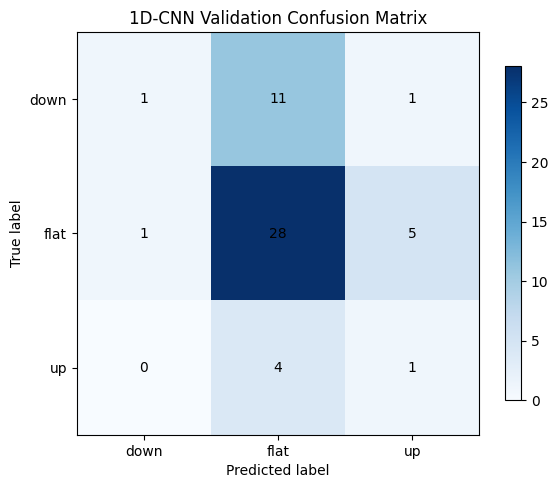

Saved plot: results/plots/cnn_1d_validation_confusion_matrix.png


In [24]:
# plot 1D-CNN validation confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm_plot = ax.imshow(
    cnn_val_cm,
    cmap="Blues"
)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)

ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)

for i in range(cnn_val_cm.shape[0]):
    for j in range(cnn_val_cm.shape[1]):
        ax.text(
            j,
            i,
            cnn_val_cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

ax.set_title("1D-CNN Validation Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(cm_plot, ax=ax, shrink=0.8)

plt.tight_layout()

plot_path = PLOTS_DIR / "cnn_1d_validation_confusion_matrix.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [25]:
# final 1D-CNN test evaluation

X_test_seq, y_test_seq = create_sequences(
    X_test_cnn_scaled,
    y_test_cnn,
    best_window_size
)

test_dataset = CNNSequenceDataset(
    X_test_seq,
    y_test_seq
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cnn_best_params["batch_size"],
    shuffle=False
)

cnn_test_pred, cnn_test_labels, cnn_test_proba = predict_cnn(
    cnn_model,
    test_loader
)

cnn_test_metrics = calculate_classification_metrics(
    y_true=cnn_test_labels,
    y_pred=cnn_test_pred,
    y_proba=cnn_test_proba
)

cnn_test_metrics_df = pd.DataFrame([{
    "model": "1D-CNN",
    "split": "test",
    **cnn_test_metrics
}])

display(cnn_test_metrics_df)

print("1D-CNN - Test Classification Report")
print(
    classification_report(
        cnn_test_labels,
        cnn_test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

cnn_test_cm = confusion_matrix(
    cnn_test_labels,
    cnn_test_pred,
    labels=CLASS_LABELS
)

cnn_test_cm_df = pd.DataFrame(
    cnn_test_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

display(cnn_test_cm_df)

print("Original test rows:", len(y_test_cnn))
print("CNN test sequence rows:", len(cnn_test_labels))
print("Dropped first test rows due to window:", best_window_size - 1)

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,1D-CNN,test,0.326923,0.319028,0.304917,0.3139,0.334519,0.319028,-0.017289,0.275862,0.416667,0.222222,0.483423,0.490316,0.362574,0.375407


1D-CNN - Test Classification Report
              precision    recall  f1-score   support

        down       0.44      0.20      0.28        20
        flat       0.34      0.53      0.42        19
          up       0.21      0.23      0.22        13

    accuracy                           0.33        52
   macro avg       0.33      0.32      0.30        52
weighted avg       0.35      0.33      0.31        52



,pred_down,pred_flat,pred_up
actual_down,4,10,6
actual_flat,4,10,5
actual_up,1,9,3


Original test rows: 54
CNN test sequence rows: 52
Dropped first test rows due to window: 2


In [26]:
# save 1D-CNN test metrics and predictions

cnn_test_metrics_df.to_csv(
    METRICS_DIR / "cnn_1d_test_metrics.csv",
    index=False
)

cnn_test_cm_df.to_csv(
    METRICS_DIR / "cnn_1d_test_confusion_matrix.csv",
    index=True
)

cnn_test_predictions_df = pd.DataFrame({
    "split": "test",
    "true_label": cnn_test_labels,
    "true_label_name": [CLASS_NAMES[int(label)] for label in cnn_test_labels],
    "pred_label": cnn_test_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in cnn_test_pred],
    "proba_down": cnn_test_proba[:, 0],
    "proba_flat": cnn_test_proba[:, 1],
    "proba_up": cnn_test_proba[:, 2],
})

cnn_test_predictions_df.to_csv(
    PREDICTIONS_DIR / "cnn_1d_test_predictions.csv",
    index=False
)

print("Saved 1D-CNN test outputs:")
print("-", METRICS_DIR / "cnn_1d_test_metrics.csv")
print("-", METRICS_DIR / "cnn_1d_test_confusion_matrix.csv")
print("-", PREDICTIONS_DIR / "cnn_1d_test_predictions.csv")

Saved 1D-CNN test outputs:
- results/metrics/cnn_1d_test_metrics.csv
- results/metrics/cnn_1d_test_confusion_matrix.csv
- results/predictions/cnn_1d_test_predictions.csv


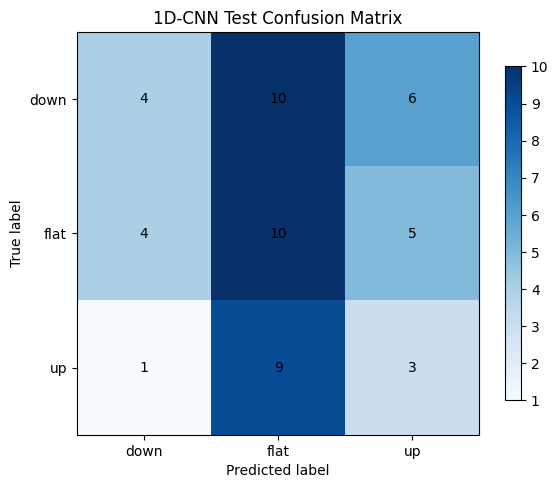

Saved plot: results/plots/cnn_1d_test_confusion_matrix.png


In [27]:
# plot 1D-CNN test confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm_plot = ax.imshow(
    cnn_test_cm,
    cmap="Blues"
)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)

ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)

for i in range(cnn_test_cm.shape[0]):
    for j in range(cnn_test_cm.shape[1]):
        ax.text(
            j,
            i,
            cnn_test_cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

ax.set_title("1D-CNN Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(cm_plot, ax=ax, shrink=0.8)

plt.tight_layout()

plot_path = PLOTS_DIR / "cnn_1d_test_confusion_matrix.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [28]:
# combine validation and test metrics for all models

TABULAR_METRICS_FILE = METRICS_DIR / "tabular_models_validation_test_metrics.csv"

tabular_metrics_df = pd.read_csv(TABULAR_METRICS_FILE)

cnn_metrics_df = pd.concat(
    [
        cnn_val_metrics_df,
        cnn_test_metrics_df
    ],
    ignore_index=True
)

all_models_metrics_df = pd.concat(
    [
        tabular_metrics_df,
        cnn_metrics_df
    ],
    ignore_index=True
)

metric_order = [
    "model",
    "split",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "precision_macro",
    "recall_macro",
    "mcc",
    "down_f1",
    "flat_f1",
    "up_f1",
    "roc_auc_macro_ovr",
    "roc_auc_weighted_ovr",
    "pr_auc_macro",
    "pr_auc_weighted"
]

all_models_metrics_df = all_models_metrics_df[
    [col for col in metric_order if col in all_models_metrics_df.columns]
]

display(all_models_metrics_df.round(4))

all_models_metrics_df.to_csv(
    METRICS_DIR / "all_models_validation_test_metrics.csv",
    index=False
)

print("Saved all model metrics:")
print("-", METRICS_DIR / "all_models_validation_test_metrics.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,validation,0.5370,0.4141,0.4237,0.5459,0.4466,0.4141,0.1198,0.5000,0.6377,0.1333,0.4764,0.4868,0.4202,0.5460
1,CatBoost,validation,0.6667,0.5640,0.5385,0.6200,0.5619,0.5640,0.3148,0.2105,0.7895,0.6154,0.6949,0.6608,0.5077,0.5829
2,Logistic Regression,test,0.4074,0.3792,0.3498,0.3716,0.3522,0.3792,0.0874,0.5098,0.4444,0.0952,0.5106,0.5168,0.3823,0.3909
3,CatBoost,test,0.2963,0.3415,0.2167,0.1977,0.2351,0.3415,0.0231,0.0000,0.2308,0.4194,0.5924,0.5910,0.4452,0.4487
4,1D-CNN,validation,0.5769,0.3668,0.3424,0.5249,0.4313,0.3668,0.0355,0.1333,0.7273,0.1667,0.4840,0.4697,0.4145,0.5086
5,1D-CNN,test,0.3269,0.3190,0.3049,0.3139,0.3345,0.3190,-0.0173,0.2759,0.4167,0.2222,0.4834,0.4903,0.3626,0.3754


Saved all model metrics:
- results/metrics/all_models_validation_test_metrics.csv


In [29]:
# final test comparison table

test_comparison_df = (
    all_models_metrics_df
    .query("split == 'test'")
    .copy()
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(test_comparison_df.round(4))

test_comparison_df.to_csv(
    METRICS_DIR / "all_models_test_comparison.csv",
    index=False
)

print("Saved test comparison:")
print("-", METRICS_DIR / "all_models_test_comparison.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,test,0.4074,0.3792,0.3498,0.3716,0.3522,0.3792,0.0874,0.5098,0.4444,0.0952,0.5106,0.5168,0.3823,0.3909
1,1D-CNN,test,0.3269,0.3190,0.3049,0.3139,0.3345,0.3190,-0.0173,0.2759,0.4167,0.2222,0.4834,0.4903,0.3626,0.3754
2,CatBoost,test,0.2963,0.3415,0.2167,0.1977,0.2351,0.3415,0.0231,0.0000,0.2308,0.4194,0.5924,0.5910,0.4452,0.4487


Saved test comparison:
- results/metrics/all_models_test_comparison.csv


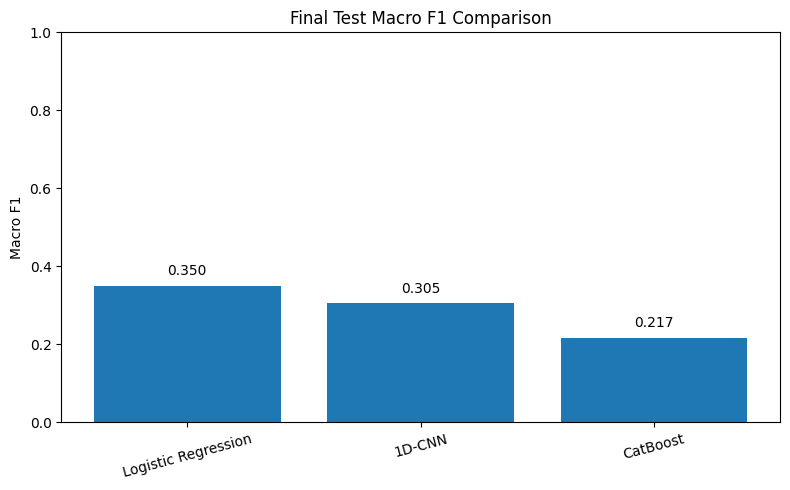

Saved plot: results/plots/all_models_test_macro_f1_comparison.png


In [30]:
# plot test macro F1 comparison

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    test_comparison_df["model"],
    test_comparison_df["macro_f1"]
)

ax.set_title("Final Test Macro F1 Comparison")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)

for i, value in enumerate(test_comparison_df["macro_f1"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()

plot_path = PLOTS_DIR / "all_models_test_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [31]:
# final direct model comparison

tabular_metrics_df = pd.read_csv(
    METRICS_DIR / "tabular_models_validation_test_metrics.csv"
)

cnn_metrics_df = pd.concat(
    [
        cnn_val_metrics_df,
        cnn_test_metrics_df
    ],
    ignore_index=True
)

final_model_comparison_df = pd.concat(
    [
        tabular_metrics_df,
        cnn_metrics_df
    ],
    ignore_index=True
)

metric_columns = [
    "model",
    "split",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "precision_macro",
    "recall_macro",
    "mcc",
    "down_f1",
    "flat_f1",
    "up_f1",
    "roc_auc_macro_ovr",
    "pr_auc_macro"
]

final_model_comparison_df = final_model_comparison_df[
    [col for col in metric_columns if col in final_model_comparison_df.columns]
]

display(final_model_comparison_df.round(4))

final_model_comparison_df.to_csv(
    METRICS_DIR / "final_model_comparison_direct.csv",
    index=False
)

print("Saved:")
print(METRICS_DIR / "final_model_comparison_direct.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,pr_auc_macro
0,Logistic Regression,validation,0.5370,0.4141,0.4237,0.5459,0.4466,0.4141,0.1198,0.5000,0.6377,0.1333,0.4764,0.4202
1,CatBoost,validation,0.6667,0.5640,0.5385,0.6200,0.5619,0.5640,0.3148,0.2105,0.7895,0.6154,0.6949,0.5077
2,Logistic Regression,test,0.4074,0.3792,0.3498,0.3716,0.3522,0.3792,0.0874,0.5098,0.4444,0.0952,0.5106,0.3823
3,CatBoost,test,0.2963,0.3415,0.2167,0.1977,0.2351,0.3415,0.0231,0.0000,0.2308,0.4194,0.5924,0.4452
4,1D-CNN,validation,0.5769,0.3668,0.3424,0.5249,0.4313,0.3668,0.0355,0.1333,0.7273,0.1667,0.4840,0.4145
5,1D-CNN,test,0.3269,0.3190,0.3049,0.3139,0.3345,0.3190,-0.0173,0.2759,0.4167,0.2222,0.4834,0.3626


Saved:
results/metrics/final_model_comparison_direct.csv


In [32]:
# direct test comparison only

direct_test_comparison_df = (
    final_model_comparison_df
    .query("split == 'test'")
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(direct_test_comparison_df.round(4))

direct_test_comparison_df.to_csv(
    METRICS_DIR / "direct_test_model_comparison.csv",
    index=False
)

print("Saved:")
print(METRICS_DIR / "direct_test_model_comparison.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,pr_auc_macro
0,Logistic Regression,test,0.4074,0.3792,0.3498,0.3716,0.3522,0.3792,0.0874,0.5098,0.4444,0.0952,0.5106,0.3823
1,1D-CNN,test,0.3269,0.3190,0.3049,0.3139,0.3345,0.3190,-0.0173,0.2759,0.4167,0.2222,0.4834,0.3626
2,CatBoost,test,0.2963,0.3415,0.2167,0.1977,0.2351,0.3415,0.0231,0.0000,0.2308,0.4194,0.5924,0.4452


Saved:
results/metrics/direct_test_model_comparison.csv


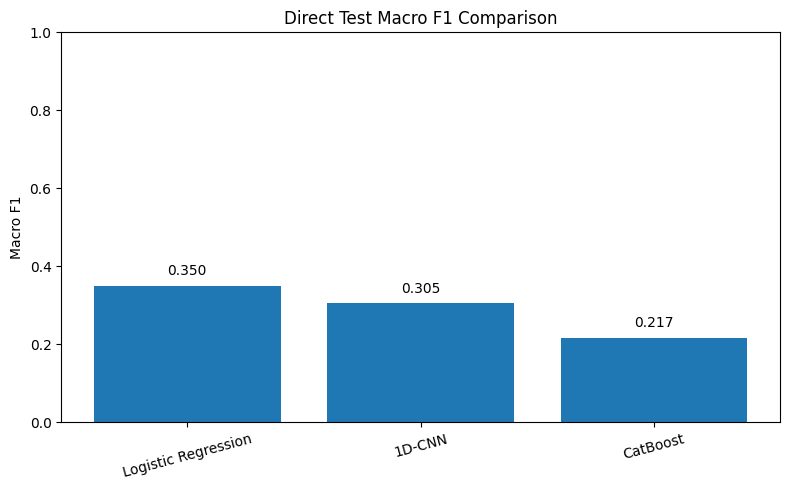

Saved plot: results/plots/direct_test_macro_f1_comparison.png


In [33]:
# direct test macro F1 comparison plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    direct_test_comparison_df["model"],
    direct_test_comparison_df["macro_f1"]
)

ax.set_title("Direct Test Macro F1 Comparison")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)

for i, value in enumerate(direct_test_comparison_df["macro_f1"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()

plot_path = PLOTS_DIR / "direct_test_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

split,model,validation,test
0,Logistic Regression,0.4237,0.3498
1,1D-CNN,0.3424,0.3049
2,CatBoost,0.5385,0.2167


Saved:
results/metrics/all_models_validation_test_macro_f1_summary.csv


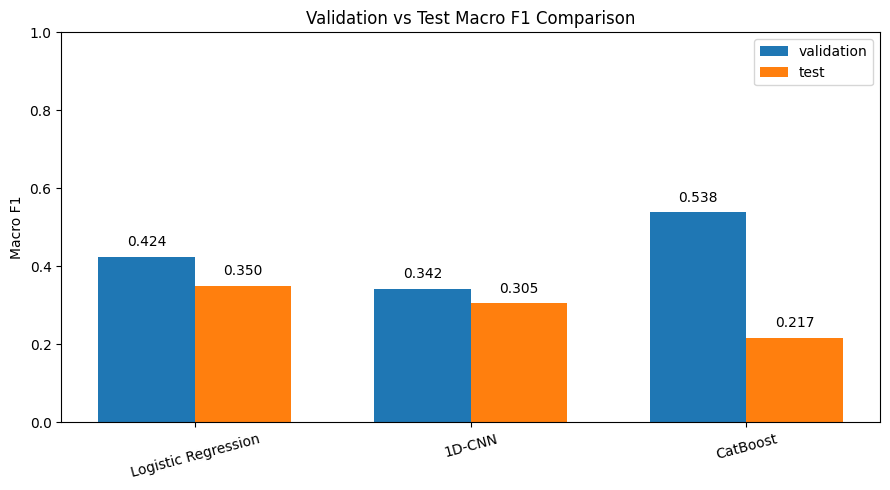

Saved plot:
results/plots/all_models_validation_test_macro_f1_comparison.png


In [ ]:
# final validation vs test macro F1 comparison for all models

tabular_metrics_df = pd.read_csv(
    METRICS_DIR / "tabular_models_validation_test_metrics.csv"
)

cnn_metrics_df = pd.concat(
    [
        cnn_val_metrics_df,
        cnn_test_metrics_df
    ],
    ignore_index=True
)

all_models_val_test_df = pd.concat(
    [
        tabular_metrics_df,
        cnn_metrics_df
    ],
    ignore_index=True
)

# keep only validation and test rows
all_models_val_test_df = all_models_val_test_df[
    all_models_val_test_df["split"].isin(["validation", "test"])
].copy()

# summary table: models in rows, validation/test scores in columns
val_test_macro_f1_table = (
    all_models_val_test_df
    .pivot_table(
        index="model",
        columns="split",
        values="macro_f1",
        aggfunc="first"
    )
    .reset_index()
)

# column order
val_test_macro_f1_table = val_test_macro_f1_table[
    ["model", "validation", "test"]
]

# (ptional) sort by test score
val_test_macro_f1_table = (
    val_test_macro_f1_table
    .sort_values("test", ascending=False)
    .reset_index(drop=True)
)

display(val_test_macro_f1_table.round(4))

val_test_macro_f1_table.to_csv(
    METRICS_DIR / "all_models_validation_test_macro_f1_summary.csv",
    index=False
)

print("Saved:")
print(METRICS_DIR / "all_models_validation_test_macro_f1_summary.csv")


# plot validation and test macro F1 side by side

plot_df = val_test_macro_f1_table.copy()

x = np.arange(len(plot_df["model"]))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_validation = ax.bar(
    x - width / 2,
    plot_df["validation"],
    width,
    label="validation"
)

bars_test = ax.bar(
    x + width / 2,
    plot_df["test"],
    width,
    label="test"
)

ax.set_title("Validation vs Test Macro F1 Comparison")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=15)
ax.legend()

for bars in [bars_validation, bars_test]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()

plot_path = PLOTS_DIR / "all_models_validation_test_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:")
print(plot_path)